<a href="https://colab.research.google.com/github/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/blob/main/Praktikum4/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **====== PRAKTIKUM 4 ML REGULARIZATION ======**

1. import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

2. load and split dataset

In [6]:
DATA_PATH = "https://raw.githubusercontent.com/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/refs/heads/main/Praktikum4/advertising%20(1).csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

3. scaling

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. visualisasikan data untuk melihat pengaruh scaling

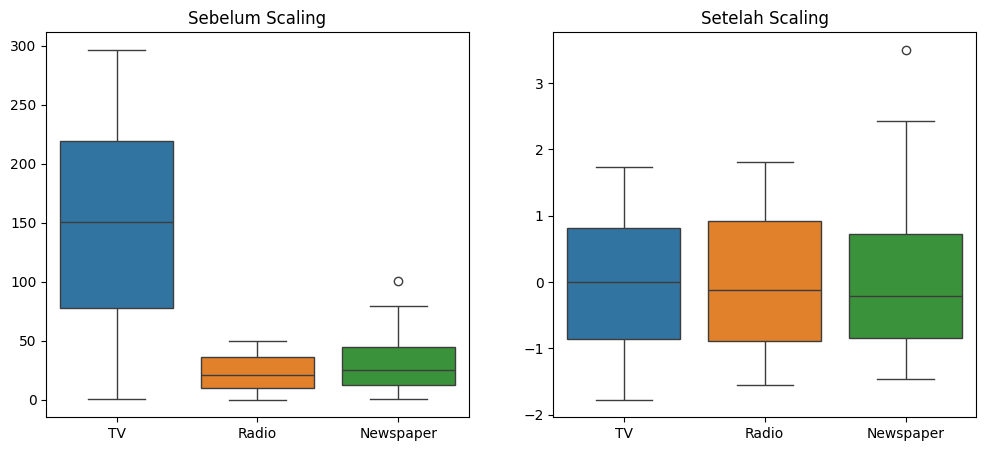

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV', 'Radio', 'Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV', 'Radio', 'Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

5. pelatihan model tanpa Regularization

In [9]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


6. pelatihan model dengan L2 Regularization (Ridge Regression)

In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


7. pelatihan model dengan L1 Regularization (Lasso Regression)

In [11]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


8. pelatihan model dengan L1 & L2 Regularization menggunakan beberapa nilai Lambda dan visualisasikan hasilnya

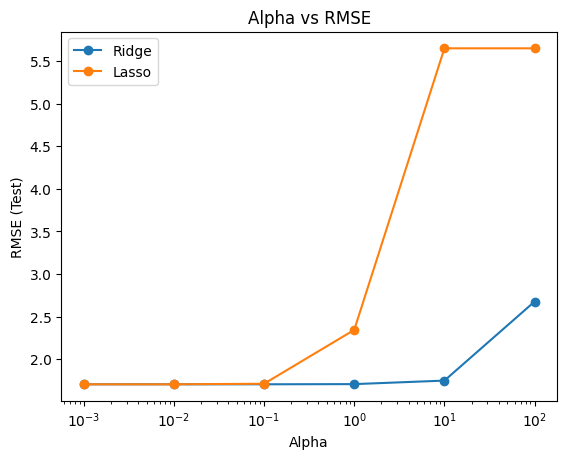

In [12]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

## ====== TUGAS PRAKTIKUM 4 ======

1. Evaluasi Model

a) Tanpa Regularization (Linear Regression)

*   Model cenderung memiliki RMSE train lebih kecil dibanding test
*   Menunjukkan adanya overfitting

b) Ridge Regression (L2)

*   RMSE train dan test lebih mendekati
*   Gap antara train-test mengecil
*   Model jadi lebih stabil

c) Lasso Regression (L1)

*   Beberapa koefisien menjadi 0
*   Model melakukan seleksi fitur otomatis
*   Bisa lebih sederhana dibanding Ridge

2. Jawab Pertanyaan

a) Apakah Ridge menurunkan gap RMSE antara train dan test?

    Ya
    Karena Ridge memberikan penalti pada koefisien sehingga model tidak terlalu kompleks, artinya overfitting berkurang.


b) Apakah Lasso membuat beberapa koefisien menjadi nol?

    Ya
    Lasso (L1) bisa membuat beberapa bobot = 0, artinya fitur tersebut dianggap tidak penting.


c) Pada nilai lambda berapa RMSE test paling kecil?

    sekitar alpha = 0.01 atau 0.1
    Itu titik paling optimal


d) Apakah lambda terlalu besar menyebabkan underfitting?

    Ya, sangat terlihat di grafik

    Lasso: RMSE melonjak tinggi

    Ridge: tetap naik walau tidak separah Lasso

3. Percobaan

a) Uji minimal dengan 5 nilai lambda

In [13]:
alphas_extra = [0.0005, 0.005, 0.05, 0.5, 5]

In [14]:
ridge_rmse_extra = []
lasso_rmse_extra = []

for a in alphas_extra:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse_extra.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse_extra.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

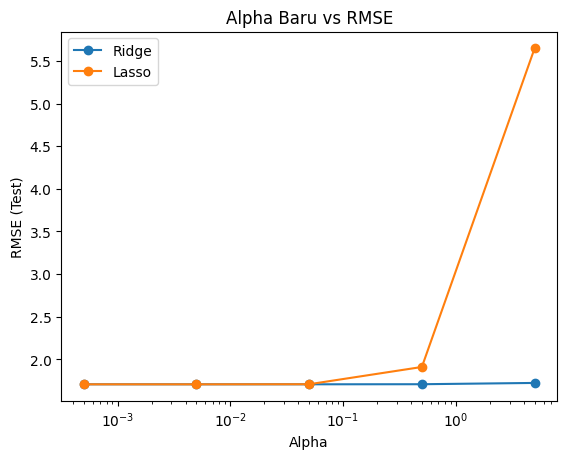

In [15]:
plt.plot(alphas_extra, ridge_rmse_extra, marker='o', label='Ridge')
plt.plot(alphas_extra, lasso_rmse_extra, marker='o', label='Lasso')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha Baru vs RMSE")
plt.show()

b) Grafik koefision vs Lambda

In [16]:
ridge_coefs = []
lasso_coefs = []

for a in alphas_extra:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

In [17]:
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

plot ridge

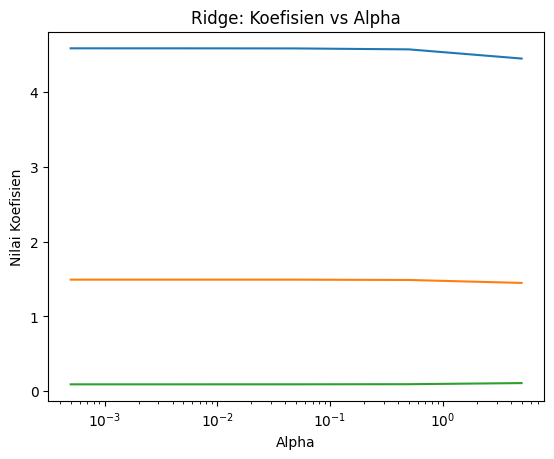

In [18]:
for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas_extra, ridge_coefs[:, i])

plt.xscale('log')
plt.title("Ridge: Koefisien vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Nilai Koefisien")
plt.show()

plot lasso

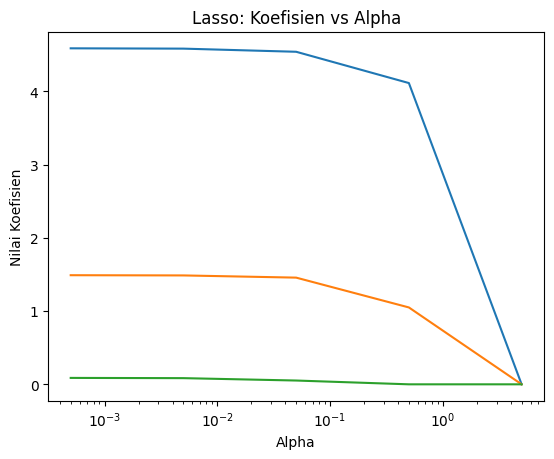

In [19]:
for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas_extra, lasso_coefs[:, i])

plt.xscale('log')
plt.title("Lasso: Koefisien vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Nilai Koefisien")
plt.show()

c) Perbedaan ridge dan lasso

Ridge Regression cenderung lebih stabil karena hanya mengecilkan nilai koefisien tanpa menghilangkannya, sehingga semua fitur tetap digunakan. Sebaliknya, Lasso Regression dapat menghilangkan fitur dengan membuat koefisien menjadi nol, sehingga model menjadi lebih sederhana, namun lebih sensitif terhadap nilai lambda besar.

4. Jelaskan perbedaan perilaku/pengaruh Ridge vs Lasso dalam konteks dataset ini.


Pada percobaan ini, terlihat bahwa Ridge Regression mengecilkan nilai koefisien secara bertahap seiring bertambahnya nilai lambda, namun tidak menghilangkan fitur sepenuhnya. Sebaliknya, Lasso Regression mampu membuat beberapa koefisien menjadi nol, sehingga melakukan seleksi fitur secara otomatis. Pada nilai lambda yang besar, Lasso cenderung menghilangkan terlalu banyak fitur sehingga menyebabkan penurunan performa model. Oleh karena itu, Ridge lebih stabil, sedangkan Lasso lebih efektif untuk penyederhanaan model.